Dataset Link: https://data.mendeley.com/datasets/rn9m3zb7nt/2

In [3]:
dataset_drive_url = "https://drive.google.com/file/d/1VTY0ff69sMqCJ_rrEgxVIteWV3Hgg6MI/view?usp=sharing"

In [4]:
import re


def drive_to_direct_url(link: str) -> str:
    """
    Convert Google Drive share link to direct download URL.
    Works for multiple link formats.
    """
    patterns = [
        r'/file/d/([a-zA-Z0-9_-]+)',
        r'id=([a-zA-Z0-9_-]+)',
        r'/open\?id=([a-zA-Z0-9_-]+)'
    ]
    
    file_id = None
    
    for pattern in patterns:
        match = re.search(pattern, link)
        if match:
            file_id = match.group(1)
            break
    
    if not file_id:
        raise ValueError("Invalid Google Drive link")
    
    return f"https://drive.google.com/uc?id={file_id}"

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [6]:
path = drive_to_direct_url(dataset_drive_url)

In [7]:
df = pd.read_csv(path)

In [8]:
df.head()

,No. of Pregnancy,Age,BMI,BP(Systolic),BP(Diastolic),DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Type-2 Diabetic,Glucose
0,3,50,22.263762,140,90.0,0,0,317.50,1,146.0
1,1,40,24.111159,110,80.0,2,0,317.50,0,61.0
2,0,21,17.183204,120,80.0,0,0,259.08,1,97.0
3,2,30,21.244332,130,85.0,0,0,322.58,1,178.0
4,2,35,22.819490,110,75.0,0,0,335.28,1,167.0


In [9]:
df.shape

(1065, 10)

In [10]:
df.columns.tolist()

['No. of Pregnancy',
 'Age',
 'BMI',
 'BP(Systolic)',
 'BP(Diastolic)',
 'DiabetesPedigreeFunction',
 'Insulin',
 'Skin Thickness(mm)',
 'Type-2 Diabetic',
 'Glucose']

In [11]:
target_col = "Type-2 Diabetic"

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065 entries, 0 to 1064
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   No. of Pregnancy          1065 non-null   int64  
 1   Age                       1065 non-null   int64  
 2   BMI                       1065 non-null   float64
 3   BP(Systolic)              1065 non-null   int64  
 4   BP(Diastolic)             1061 non-null   float64
 5   DiabetesPedigreeFunction  1065 non-null   int64  
 6   Insulin                   1065 non-null   int64  
 7   Skin Thickness(mm)        1058 non-null   float64
 8   Type-2 Diabetic           1065 non-null   int64  
 9   Glucose                   1065 non-null   float64
dtypes: float64(4), int64(6)
memory usage: 83.3 KB


In [13]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

categorical_cols

[]

In [14]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols

['No. of Pregnancy',
 'Age',
 'BMI',
 'BP(Systolic)',
 'BP(Diastolic)',
 'DiabetesPedigreeFunction',
 'Insulin',
 'Skin Thickness(mm)',
 'Type-2 Diabetic',
 'Glucose']

In [15]:
df.isnull().sum()

No. of Pregnancy            0
Age                         0
BMI                         0
BP(Systolic)                0
BP(Diastolic)               4
DiabetesPedigreeFunction    0
Insulin                     0
Skin Thickness(mm)          7
Type-2 Diabetic             0
Glucose                     0
dtype: int64

The missing values are pretty low, so there’s no need to remove the features. We can handle them through imputation. `BP(Diastolic)` has 4 missing values, and `Skin Thickness(mm)` has 7 missing values.


In [16]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
No. of Pregnancy,1065.0,3.114554,1.878355,0.000000,2.000000,3.000000,4.000000,12.000000
Age,1065.0,44.467606,12.695950,21.000000,35.000000,44.000000,53.000000,86.000000
BMI,1065.0,25.246733,3.800444,17.183204,22.650587,24.603224,27.492665,37.442807
BP(Systolic),1065.0,119.350235,14.289513,80.000000,110.000000,120.000000,130.000000,180.000000
BP(Diastolic),1061.0,79.829406,10.770160,30.000000,70.000000,80.000000,80.000000,120.000000
DiabetesPedigreeFunction,1065.0,1.487324,1.560822,0.000000,0.000000,1.000000,2.000000,8.000000
Insulin,1065.0,5.406573,8.879252,0.000000,0.000000,0.000000,12.000000,44.000000
Skin Thickness(mm),1058.0,307.242769,35.366131,29.210000,287.020000,304.800000,330.200000,406.400000
Type-2 Diabetic,1065.0,0.788732,0.408400,0.000000,1.000000,1.000000,1.000000,1.000000
Glucose,1065.0,138.448920,64.832444,50.000000,80.000000,129.000000,178.000000,450.000000


In [17]:
df.nunique()

No. of Pregnancy             13
Age                          55
BMI                         185
BP(Systolic)                 15
BP(Diastolic)                14
DiabetesPedigreeFunction      8
Insulin                      21
Skin Thickness(mm)           40
Type-2 Diabetic               2
Glucose                     146
dtype: int64

In [18]:
df[df.duplicated(keep=False)].shape

(888, 10)

The dataframe contains 1,065 rows and 10 columns. Among these, 888 rows belong to groups of exact duplicate records, including the first occurrence of each duplicate. The remaining 569 rows are additional duplicate copies. Since this represents a significant amount of duplication, we should remove the duplicate rows before continuing the analysis.


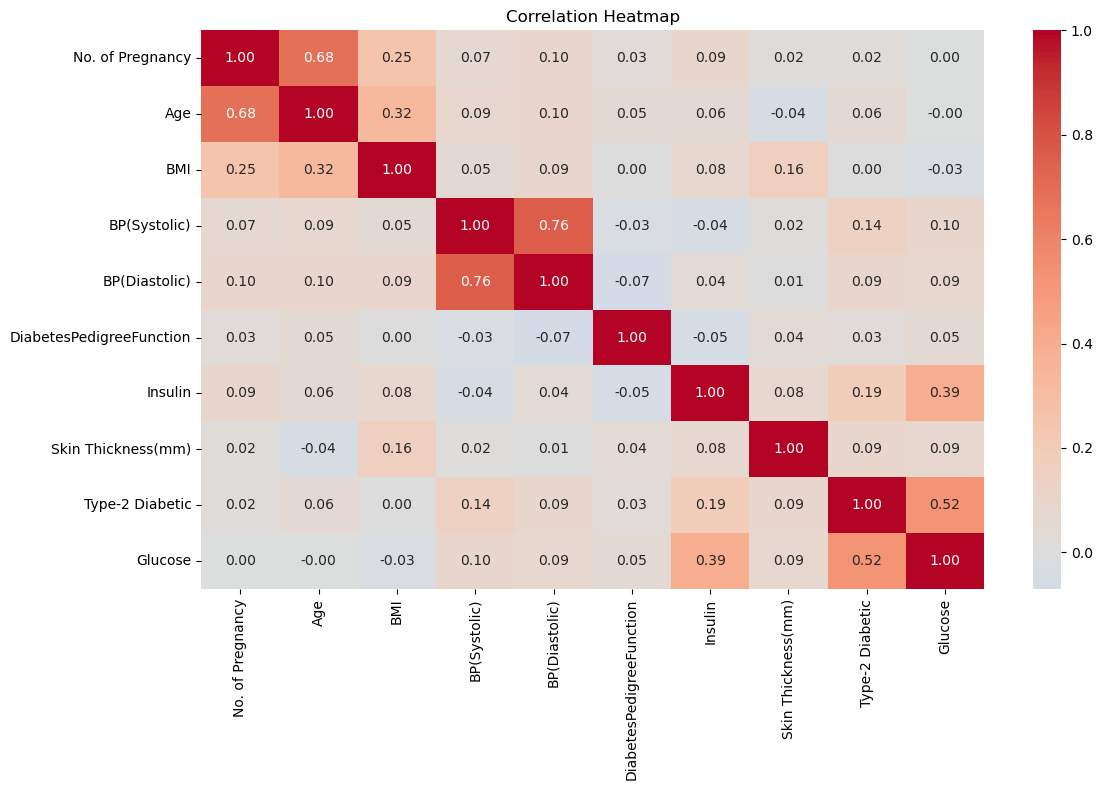

In [20]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Glucose had the strongest correlation with Type-2 Diabetes (0.525), while the remaining features showed weak or very weak correlations. However, no feature showed a strong enough correlation to justify removal. Therefore, all features were retained for further analysis.

In [21]:
df = df.drop_duplicates().reset_index(drop=True)

In [22]:
df.shape

(496, 10)

In [23]:
df[df.duplicated(keep=False)].shape

(0, 10)

In [24]:
df.isnull().sum()

No. of Pregnancy            0
Age                         0
BMI                         0
BP(Systolic)                0
BP(Diastolic)               4
DiabetesPedigreeFunction    0
Insulin                     0
Skin Thickness(mm)          7
Type-2 Diabetic             0
Glucose                     0
dtype: int64

In [25]:
df["BP(Diastolic)"]

0       90.0
1       80.0
2       80.0
3       85.0
4       75.0
       ...  
491     60.0
492    110.0
493     70.0
494     70.0
495     80.0
Name: BP(Diastolic), Length: 496, dtype: float64

In [26]:
df["BP(Diastolic)"] = df["BP(Diastolic)"].fillna(
    df["BP(Diastolic)"].median()
)

In [27]:
df["Skin Thickness(mm)"]

0      317.50
1      317.50
2      259.08
3      322.58
4      335.28
        ...  
491    284.48
492       NaN
493    317.50
494    304.80
495       NaN
Name: Skin Thickness(mm), Length: 496, dtype: float64

In [28]:
df["Skin Thickness(mm)"] = df["Skin Thickness(mm)"].fillna(
    df["Skin Thickness(mm)"].median()
)

BP(Diastolic) and Skin Thickness(mm) contained 4 and 7 missing values, respectively. Since the proportion of missing values was small, the observations were retained and missing values were imputed using the median to reduce the influence of potential outliers.

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   No. of Pregnancy          496 non-null    int64  
 1   Age                       496 non-null    int64  
 2   BMI                       496 non-null    float64
 3   BP(Systolic)              496 non-null    int64  
 4   BP(Diastolic)             496 non-null    float64
 5   DiabetesPedigreeFunction  496 non-null    int64  
 6   Insulin                   496 non-null    int64  
 7   Skin Thickness(mm)        496 non-null    float64
 8   Type-2 Diabetic           496 non-null    int64  
 9   Glucose                   496 non-null    float64
dtypes: float64(4), int64(6)
memory usage: 38.9 KB


In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
No. of Pregnancy,496.0,3.054435,1.848576,0.000000,2.00000,3.000000,4.000000,12.000000
Age,496.0,44.183468,12.808008,21.000000,35.00000,42.000000,52.250000,86.000000
BMI,496.0,25.155703,3.766701,17.183204,22.58069,24.578353,27.336915,37.442807
BP(Systolic),496.0,119.014113,13.734782,80.000000,110.00000,120.000000,125.250000,180.000000
BP(Diastolic),496.0,79.340726,10.599544,30.000000,70.00000,80.000000,80.000000,120.000000
DiabetesPedigreeFunction,496.0,1.536290,1.638764,0.000000,0.00000,1.000000,2.000000,8.000000
Insulin,496.0,5.108871,8.965266,0.000000,0.00000,0.000000,10.000000,44.000000
Skin Thickness(mm),496.0,307.567883,34.478487,29.210000,284.48000,304.800000,330.200000,406.400000
Type-2 Diabetic,496.0,0.760081,0.427465,0.000000,1.00000,1.000000,1.000000,1.000000
Glucose,496.0,137.351008,64.364270,50.000000,80.00000,126.500000,172.250000,450.000000


In [31]:
feature_cols = df.columns.drop(target_col)

Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (df[feature_cols] < lower_bound) |
    (df[feature_cols] > upper_bound)
)

outliers.sum()



No. of Pregnancy            16
Age                          5
BMI                         12
BP(Systolic)                15
BP(Diastolic)               34
DiabetesPedigreeFunction    12
Insulin                     19
Skin Thickness(mm)           6
Glucose                      7
dtype: int64

IQR-based analysis identified potential outliers across all numerical features, with BP (Diastolic) having the highest number (34). These observations were retained initially, as extreme values in clinical data may represent genuine patient characteristics.

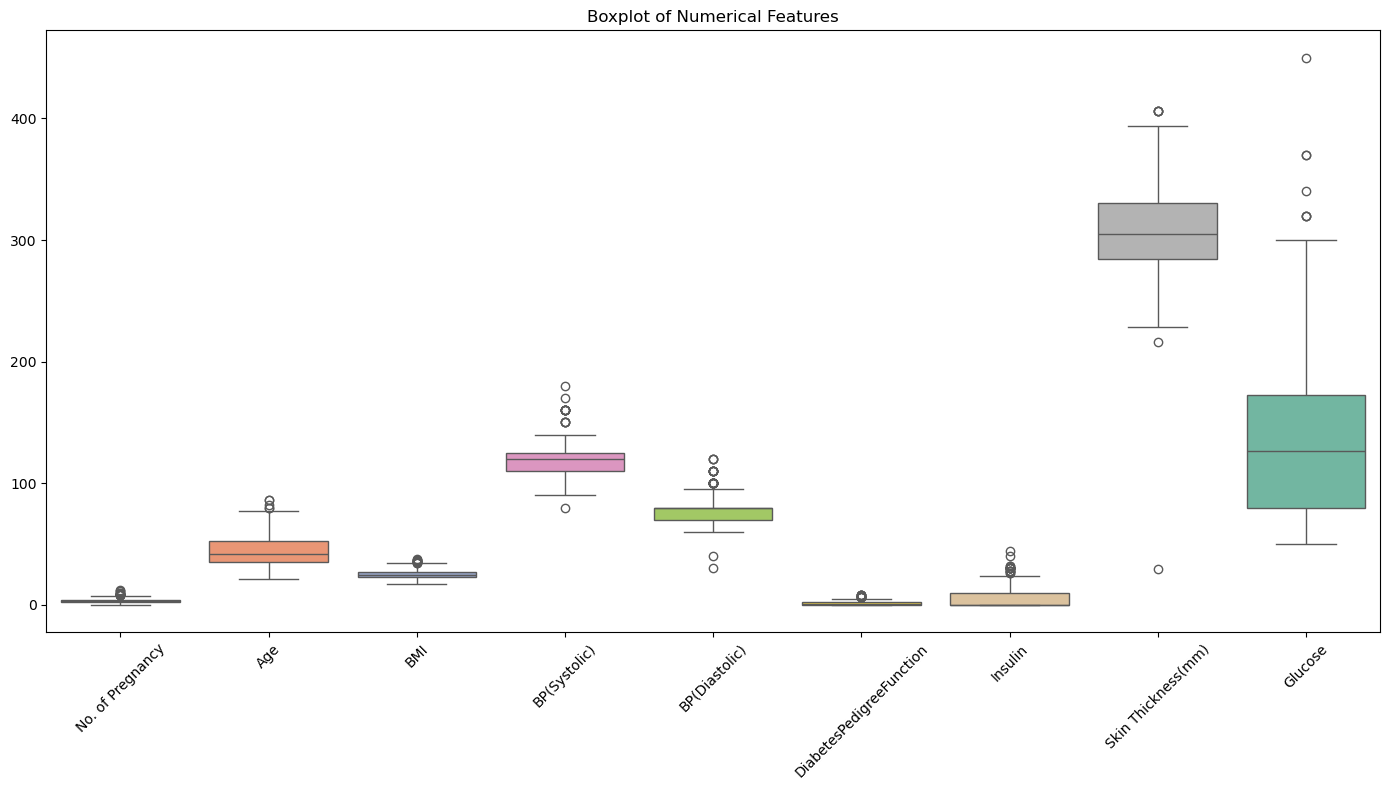

In [32]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=df[feature_cols], palette="Set2")

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

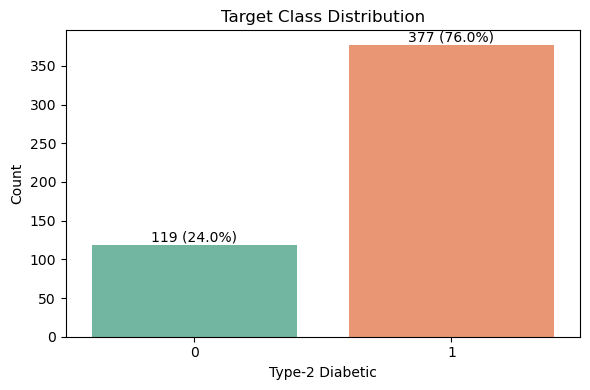

In [33]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x=target_col,
    palette="Set2",
    hue=target_col,
    legend=False
)

total = len(df)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.0f} ({bar.get_height()/total:.1%})"
        for bar in container
    ]
    ax.bar_label(container, labels=labels)

plt.title("Target Class Distribution")
plt.xlabel("Type-2 Diabetic")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

The target class distribution is imbalanced, with a higher proportion of diabetic individuals, accounting for approximately 76% of the dataset.